# Condition experiment for reduced system

How do the slack variables and lagrange multiplier change the condition of my matrix?

In [1]:
import numpy as np
import pandas as pd
import copy as copy
import scipy
import scipy.io
import time
import os
from scipy.linalg import solve, LinAlgWarning
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from matplotlib.animation import FuncAnimation, PillowWriter
import openpyxl
import xlsxwriter

from IPM_functions import (
    create_result_dataframes,
    update_result_dataframes,
    paso_intpoint,
    solve_catch_error,
    update_active_set_mask,
    active_set_diagnostics,
    progress_summary_df_clean,
    build_reduced_system,
    load_lp_problem,
    export_latex_tables,
    export_summary_to_latex
)

#from inpoint_methods import intpoint, intpointR, #,intpointR_mask

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

Loading problem from: lp_kb2.mat
Norma infinita de b:  0.0
Problem loaded. n=68, m=43, p=68
Number of zeros in b: 43 (100.00%)


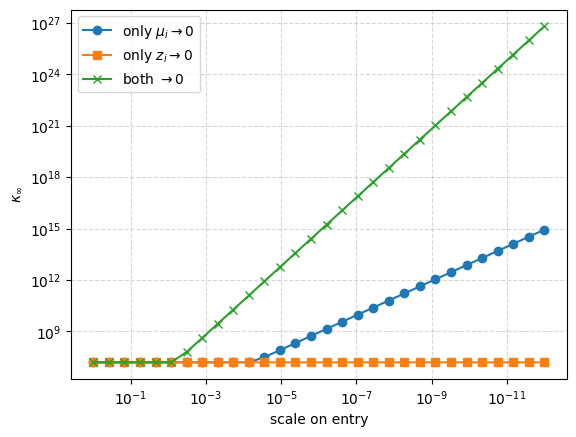

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from IPM_functions import load_lp_problem   # whatever module has it

# --- Load the problem ---
mat_file = 'lp_kb2.mat'
Q, c, A, b, F, d, H = load_lp_problem(mat_file)
n, m, p = Q.shape[0], A.shape[0], F.shape[0]

# --- Pick a baseline mu, z to study ---
# Option A: neutral baseline (isolates the block structure from any IPM iterate)
mu_base = np.ones(p)
z_base  = np.ones(p)

# Option B: rerun the IPM in this notebook and snapshot mu, z at some iteration k
# mu_base = mu.copy(); z_base = z.copy()

# --- Build the system as a function of mu, z ---
def build_system(mu, z):
    D_mu = np.diag(mu)
    AT, FT = A.T, F.T
    fila1 = np.hstack((Q, -AT, -FT @ D_mu))
    fila2 = np.hstack((-A, np.zeros((m, m + p))))
    fila3 = np.hstack((-D_mu @ F, np.zeros((p, m)), -np.diag(mu * z)))
    return np.vstack((fila1, fila2, fila3))

# --- Sweep ---
idx = 0
scales = np.logspace(0, -12, 30)

cond_mu, cond_z, cond_both = [], [], []
for s in scales:
    mu_t = mu_base.copy(); mu_t[idx] *= s
    z_t  = z_base.copy();  z_t[idx]  *= s

    cond_mu.append(  np.linalg.cond(build_system(mu_t,    z_base), np.inf))
    cond_z.append(   np.linalg.cond(build_system(mu_base, z_t   ), np.inf))
    cond_both.append(np.linalg.cond(build_system(mu_t,    z_t   ), np.inf))

plt.loglog(scales, cond_mu,   marker='o', label=r'only $\mu_i \to 0$')
plt.loglog(scales, cond_z,    marker='s', label=r'only $z_i \to 0$')
plt.loglog(scales, cond_both, marker='x', label=r'both $\to 0$')
plt.gca().invert_xaxis()
plt.xlabel('scale on entry'); plt.ylabel(r'$\kappa_\infty$')
plt.legend(); plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()